In [1]:
# Task 4 - Sentiment Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load IMDb sentiment dataset

url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# Basic dataset inspection

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

print("\nData types:")
print(df.dtypes)

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate rows: 418

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Data types:
review       object
sentiment    object
dtype: object


Duplicates removed: 418
New shape: (49582, 2)


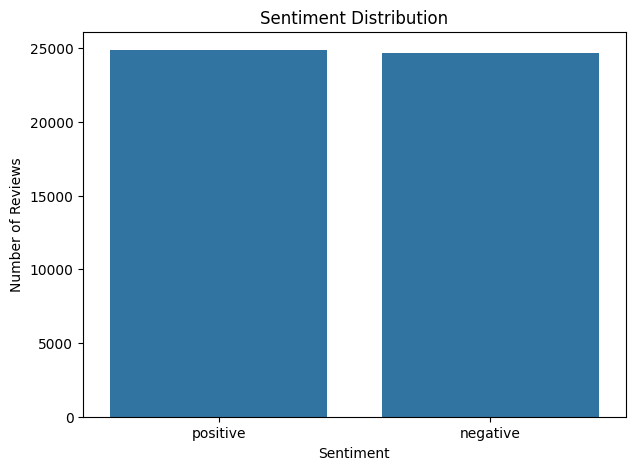

In [5]:
# Remove duplicate reviews

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates removed: 418")
print("New shape:", df.shape)

# Sentiment distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="sentiment")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [6]:
# Text preprocessing

import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)          # Remove HTML tags
    text = re.sub(r"http\S+|www\S+", " ", text) # Remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)       # Keep letters only
    text = re.sub(r"\s+", " ", text).strip()    # Remove extra spaces
    return text

df["clean_review"] = df["review"].apply(clean_text)

print(df[["review", "clean_review", "sentiment"]].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        clean_review sentiment  
0  one of the other reviewers has mentioned that ...  positive  
1  a wonderful little production the filming tech...  positive  
2  i thought this was a wonderful way to spend ti...  positive  
3  basically there s a family where a little boy ...  negative  
4  petter mattei s love in the time of money is a...  positive  


In [7]:
# TF-IDF Feature Extraction

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = tfidf.fit_transform(df["clean_review"])
y = df["sentiment"].map({"positive": 1, "negative": 0})

print("TF-IDF completed successfully!")
print("Feature matrix shape:", X.shape)

TF-IDF completed successfully!
Feature matrix shape: (49582, 5000)


In [8]:
# Split dataset into 80% training and 20% testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 39665
Testing samples: 9917


In [9]:
# Naive Bayes Model

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Results")
print("Accuracy :", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall   :", recall_score(y_test, nb_pred))
print("F1 Score :", f1_score(y_test, nb_pred))

Naive Bayes Results
Accuracy : 0.8536855904003227
Precision: 0.8492472266244057
Recall   : 0.8613622664255576
F1 Score : 0.8552618453865337


In [10]:
# Logistic Regression Model

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Results")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

Logistic Regression Results
Accuracy : 0.8853483916507008
Precision: 0.8751465416178195
Recall   : 0.8999397227245328
F1 Score : 0.887369985141159


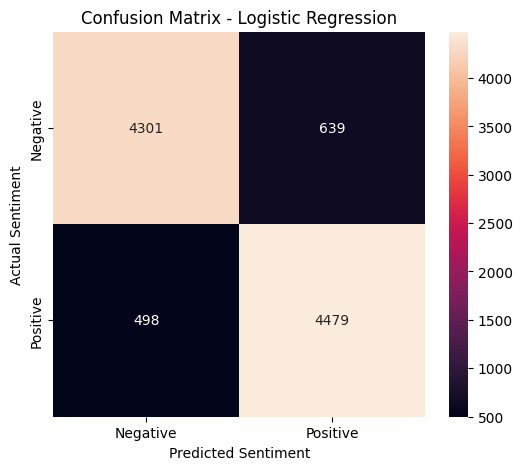

Confusion Matrix:
[[4301  639]
 [ 498 4479]]


In [11]:
# Confusion Matrix - Logistic Regression

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

print("Confusion Matrix:")
print(cm)

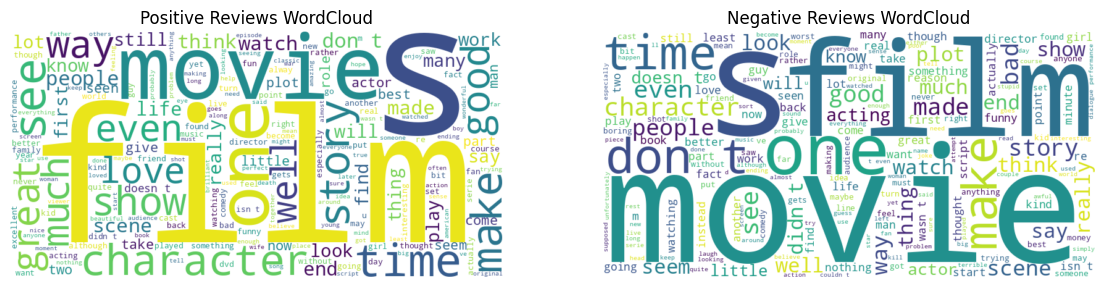

In [12]:
# WordCloud for Positive and Negative Reviews

from wordcloud import WordCloud

positive_text = " ".join(df[df["sentiment"] == "positive"]["clean_review"])
negative_text = " ".join(df[df["sentiment"] == "negative"]["clean_review"])

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
positive_wc = WordCloud(width=800, height=400, background_color="white").generate(positive_text)
plt.imshow(positive_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews WordCloud")

plt.subplot(1, 2, 2)
negative_wc = WordCloud(width=800, height=400, background_color="white").generate(negative_text)
plt.imshow(negative_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews WordCloud")

plt.show()

In [13]:
# Find 5 misclassified reviews

results = pd.DataFrame({
    "Review": df.loc[y_test.index, "review"].values,
    "Actual": y_test.map({0: "negative", 1: "positive"}).values,
    "Predicted": pd.Series(lr_pred).map({0: "negative", 1: "positive"}).values
})

misclassified = results[results["Actual"] != results["Predicted"]].head(5)

print("5 Misclassified Examples:\n")
for i, row in misclassified.iterrows():
    print(f"Example {i+1}")
    print("Actual   :", row["Actual"])
    print("Predicted:", row["Predicted"])
    print("Review   :", row["Review"])
    print("-" * 80)

5 Misclassified Examples:

Example 16
Actual   : positive
Predicted: negative
Review   : This isn't exactly a great film, but I admire the writers and director for trying something a little different. The film's main theme is fate and small, seemingly insignificant things that can greatly change the future. In some ways this reminds me of the film SLIDING DOORS, though instead of focusing on one random event, seemingly random stuff happens repeatedly and each one helps build to the cute conclusion. Plus, an odd bald guy seems to understand all this and he talks about this during one brief scene--like he's some sort of omnipotent being but there's absolutely no explanation of him in the film (like the two guys that fight each other in the clock tower in THE HUDSUCKER PROXY).<br /><br />The DVD jacket shows just Audrey Tautou. This is capitalize on her success in AMELIE, though she is only one of many actors in the film and there is no one starring role. The pace is brisk, the acting fin

In [14]:
# Classification Report - Logistic Regression

from sklearn.metrics import classification_report

print("Classification Report - Logistic Regression\n")

print(
    classification_report(
        y_test,
        lr_pred,
        target_names=["Negative", "Positive"]
    )
)

Classification Report - Logistic Regression

              precision    recall  f1-score   support

    Negative       0.90      0.87      0.88      4940
    Positive       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [15]:
# Model Comparison

comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_pred),
        precision_score(y_test, lr_pred)
    ],
    "Recall": [
        recall_score(y_test, nb_pred),
        recall_score(y_test, lr_pred)
    ],
    "F1 Score": [
        f1_score(y_test, nb_pred),
        f1_score(y_test, lr_pred)
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.8537,0.8492,0.8614,0.8553
1,Logistic Regression,0.8853,0.8751,0.8999,0.8874


## Final Insights

- The dataset contained 50,000 movie reviews with positive and negative sentiment labels.
- 418 duplicate reviews were removed, leaving 49,582 reviews for analysis.
- Text preprocessing included lowercasing, HTML removal, URL removal, special-character removal, and whitespace cleaning.
- TF-IDF was used to convert reviews into numerical features.
- Two classification models were evaluated: Multinomial Naive Bayes and Logistic Regression.
- Logistic Regression achieved 88.53% accuracy and an F1-score of 88.74%.
- Five misclassified reviews were examined to understand model errors.
- Misclassifications can occur when reviews contain mixed opinions, subtle language, context, or ambiguous sentiment.
- The analysis demonstrates how machine-learning models can be used for automated sentiment classification of movie reviews.